# **Mini Project**

Load the Fashion MNIST dataset.



In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

Explore the dataset (shape, labels, sample images).

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
Min pixel value: 0
Max pixel value: 255


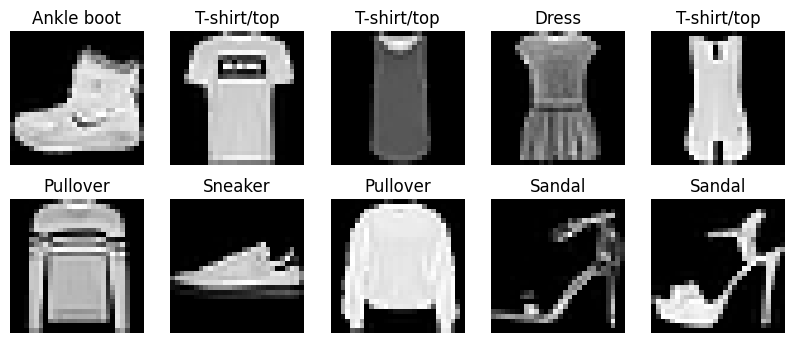

In [19]:

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()


Normalize the pixel values.


In [20]:

X_train = X_train / 255.0
X_test = X_test / 255.0


Build a simple Artificial Neural Network (ANN).


In [21]:
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Train the model.


In [22]:

history = model.fit(X_train, y_train, epochs=10, validation_split=0.1)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8213 - loss: 0.5010 - val_accuracy: 0.8503 - val_loss: 0.3999
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8646 - loss: 0.3720 - val_accuracy: 0.8637 - val_loss: 0.3909
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8756 - loss: 0.3397 - val_accuracy: 0.8715 - val_loss: 0.3529
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8824 - loss: 0.3160 - val_accuracy: 0.8763 - val_loss: 0.3349
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8902 - loss: 0.2955 - val_accuracy: 0.8782 - val_loss: 0.3329
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8966 - loss: 0.2800 - val_accuracy: 0.8767 - val_loss: 0.3425
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8999 - loss: 0.2685 - val_accuracy: 0.8807 - val_loss: 0.3389
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9050 - loss: 0.2562 -

Evaluate the model on the test dataset.


In [23]:

test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8801 - loss: 0.3571
Test accuracy: 0.8801000118255615


Display the training and validation accuracy.


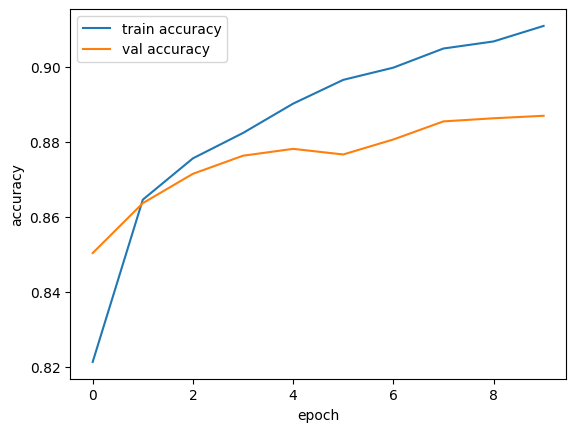

In [24]:

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()


Make predictions on a few test images.
Display the predicted and actual labels.


In [25]:

predictions = model.predict(X_test[:10])

for i in range(10):
    predicted_label = np.argmax(predictions[i])
    print("Predicted:", class_names[predicted_label], " Actual:", class_names[y_test[i]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted: Ankle boot  Actual: Ankle boot
Predicted: Pullover  Actual: Pullover
Predicted: Trouser  Actual: Trouser
Predicted: Trouser  Actual: Trouser
Predicted: Shirt  Actual: Shirt
Predicted: Trouser  Actual: Trouser
Predicted: Coat  Actual: Coat
Predicted: Shirt  Actual: Shirt
Predicted: Sandal  Actual: Sandal
Predicted: Sneaker  Actual: Sneaker
